## Car price prediction
## Objective--
## Predict the selling price of a used car using multiple Linear Regression
## Machine Learning Problem:- Regression
## Model:- Multiple Linear Regression

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [3]:
df = pd.read_csv("/content/05_car_price.csv")
df

,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Selling_Price
0,Tata Nexon,2018,15.84,111373,Petrol,Dealer,Manual,0,2.71
1,Mahindra XUV500,2012,29.24,63719,Petrol,Individual,Manual,0,5.13
2,Tata Nexon,2016,7.05,147798,Diesel,Dealer,Manual,0,0.50
3,Mahindra XUV500,2013,24.50,136164,Diesel,Individual,Automatic,0,0.50
4,Tata Nexon,2021,3.12,34995,Petrol,Dealer,Manual,1,1.81
...,...,...,...,...,...,...,...,...,...
995,Toyota Innova,2013,23.96,73657,Petrol,Dealer,Manual,0,1.70
996,Toyota Innova,2025,9.22,79652,CNG,Dealer,Manual,0,4.78
997,Hyundai i20,2014,14.40,75507,Petrol,Individual,Automatic,1,0.96
998,Maruti Swift,2022,11.43,135007,Petrol,Dealer,Manual,1,1.41


In [4]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       1000 non-null   object 
 1   Year           1000 non-null   int64  
 2   Present_Price  1000 non-null   float64
 3   Kms_Driven     1000 non-null   int64  
 4   Fuel_Type      1000 non-null   object 
 5   Seller_Type    1000 non-null   object 
 6   Transmission   1000 non-null   object 
 7   Owner          1000 non-null   int64  
 8   Selling_Price  1000 non-null   float64
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Year,Present_Price,Kms_Driven,Owner,Selling_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2018.628000,19.092310,81686.502000,0.559000,5.505620
std,3.944258,9.104675,42270.003874,0.759668,5.301802
min,2012.000000,3.050000,5059.000000,0.000000,0.500000
25%,2015.000000,11.177500,46072.000000,0.000000,1.087500
50%,2019.000000,18.925000,83586.500000,0.000000,3.790000
75%,2022.000000,26.925000,118404.750000,1.000000,8.160000
max,2025.000000,34.960000,149959.000000,3.000000,25.930000


In [7]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0
Selling_Price,0


In [8]:
df.columns

Index(['Car_Name', 'Year', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Selling_Price'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
X = df.drop("Selling_Price",axis=1)
y = df["Selling_Price"]

In [13]:
X.select_dtypes(include="object").columns

Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')

In [17]:
X = pd.get_dummies(X,drop_first=True)

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [19]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

In [22]:
print("MAE:",mae)
print("MSE",mse)
print("R2 SCORE",r2)

MAE: 1.9140806101839594
MSE 6.234426799664253
R2 SCORE 0.7903604072391022


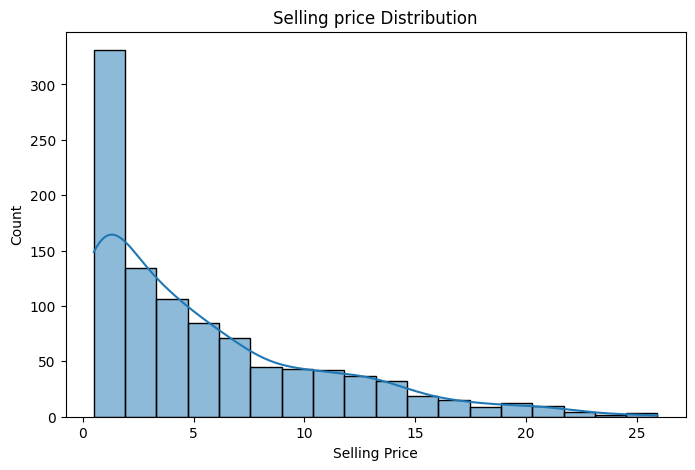

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
sns.histplot(df["Selling_Price"],kde=True)
plt.title("Selling price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Count")
plt.show()

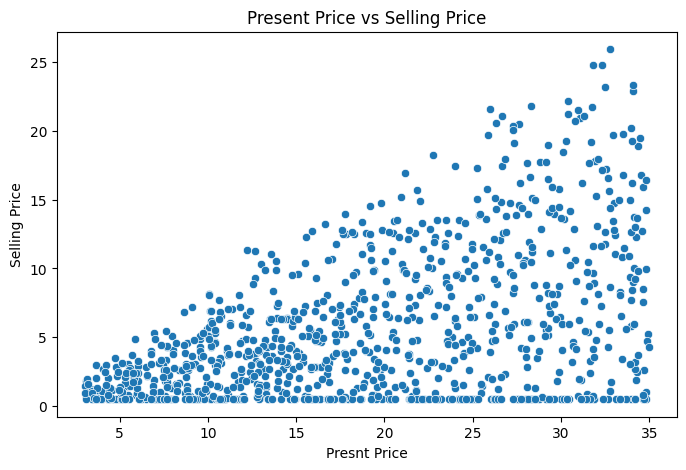

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Present_Price"],y=df["Selling_Price"])
plt.title("Present Price vs Selling Price")
plt.xlabel("Presnt Price")
plt.ylabel("Selling Price")
plt.show()

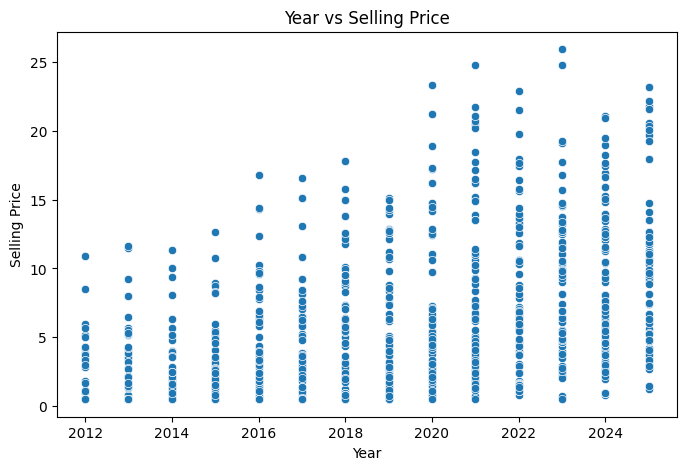

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Year"],y=df["Selling_Price"])
plt.title("Year vs Selling Price")
plt.xlabel("Year")
plt.ylabel("Selling Price")
plt.show()

In [28]:
import pickle
with open("car_price_model.pkl","wb") as file:
  pickle.dump(model,file)